# LSTM_SSL — Self-Supervised LSTM for Multi-Target Reconstruction

This notebook demonstrates how to train and evaluate a self-supervised LSTM (`LSTM_SSL`)
with channel masking.

## Concept

Self-supervised learning takes **all** dynamic context as input variables, and during
training masks configured subsets in each sample. Each forward pass:

- A configurable number of *units* (single variables or conditional bundles) is drawn
  per masking group, per sample. See `mask_groups` / `mask_counts` in the config.
- Masked positions are replaced by a single **learnable mask token** (with optional
  Gaussian noise). NaN values in the raw inputs are replaced by the same token —
  **missing observations naturally become part of the training signal**.
- Currently the **entire sequence** of a selected channel is masked (full-channel
  masking). Partial-sequence (patch-style) masking is a planned extension.

## Loss

`MaskedMSE` computes the MSE **only on positions where the input was masked** and the
observation is available. Per target variable the MSE is calculated, then the
per-target MSEs are summed up and averaged across variables. This `variable`-aggregation ensures
every target contributes equally to the training signal, even if their sample
coverage differs by orders of magnitude (e.g. continuous discharge vs. sparse water
quality).

## Evaluation scenarios

Inference scenarios are defined directly in the config under `eval_scenarios`.
Each scenario lists `mask_vars` — the variables that should be forced to the
mask token at the input. `SSLTester` runs the standard evaluation loop once per
scenario and writes the predictions to a separate zarr file per scenario at
`<save_folder>/<period>_results_<scenario_name>.zarr`. Multiple scenarios per run
are supported. Validation during training is turned off. 

## Use cases

- **Multi-target reconstruction** of sparse, irregularly sampled variables (the
  driving paper application: stream water quality alongside discharge).
  A straight forward usecase would be the extension of the e.g. CAMELS-US dataset with CAMELS-CHEM. For easy integration (bypassing any changes in the basedataset.py) one could extend the .csv from CAMELS-US with the respective columns (variables) from CAMELS-CHEM-
- **Imputation** of spotty time series — at inference, set the missing channels.
  values to NaN and the model fills them via the mask token.

## Config

All hyperparameters for this example are in
[`../examples/configs/camels_de_ssl.yml`](../examples/configs/camels_de_ssl.yml).
The example uses CAMELS-DE only; the architecture is designed for sparse datasets
and any combination of dynamic inputs / targets defined there is supported.

Authors:
- Eduardo Acuña Espinoza (eduardo.espinoza@kit.edu)
- Manuel Alvarez Chaves (manuel.alvarez-chaves@uwaterloo.c)
- Jean-Paul Brede (jean-paul.brede@outlook.de)
- Claude Opus 4.7 (by Anthropic)

In [1]:
from hy2dl.datasetzoo import get_dataset
from hy2dl.evaluation import calculate_metrics, get_tester
from hy2dl.modelzoo import get_model
from hy2dl.training.basetrainer import BaseTrainer
from hy2dl.utils.config import Config
import torch, xarray as xr, time, datetime, shutil
from pathlib import Path

base_dir = Path.cwd().resolve()



c:\Users\dj6426\AppData\Local\miniconda3\envs\ML_surface_runoff_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Part 1. Initialize information

In [10]:
# Path to .yml file where the experiment settings are stored.
path_experiment_settings = "../examples/configs/camels_de_ssl.yml"

# Read experiment settings
config = Config(path_experiment_settings, base_dir=base_dir)
config.init_experiment()
config.dump()

Dataset = get_dataset(config)
Tester = get_tester(config)   
print(Tester.__name__)

SSLTester


Part 2. Create datasets and dataloaders used to train/validate the model

In [11]:
# Create training dataset
training_dataset = Dataset(cfg=config, time_period="training")
training_dataset.setup_dataset(check_nan=False)   # SSL: check_nan should be false. the model replaces NaNs automatically with a trainable token
trainer = BaseTrainer(cfg=config, training_dataset=training_dataset)

2026-06-23 13:43:54 - Creating training dataset in memory...


Processing gauges: 100%|##########| 5/5 [00:04<00:00,  1.13entity/s]


2026-06-23 13:44:01 - Dataset created successfully.
2026-06-23 13:44:01 - Validating samples...


Validating samples: 100%|##########| 41/41 [00:00<00:00, 2582.12tasks/s]

2026-06-23 13:44:01 - Number of gauges with valid samples: 5
2026-06-23 13:44:01 - Number of valid samples: 53 420
2026-06-23 13:44:01 - Mapping ids, dates and features to their corresponding indexes


2026-06-23 13:44:01 - Dataset was successfully standardized.
2026-06-23 13:44:01 - Static attributes were successfully standardized.
2026-06-23 13:44:01 - Time required to process the dataset: 0:00:07
2026-06-23 13:44:30 - ----------------Details training dataloader-----------------
2026-06-23 13:44:30 - Batch structure (number of batches: 208)
2026-06-23 13:44:30 -              Key              |            Shape             
2026-06-23 13:44:44 - x_d
2026-06-23 13:44:44 -       precipitation_mean      |    torch.Size([256, 365])    
2026-06-23 13:44:44 -      precipitation_stdev      |    torch.Size([256, 365])    
2026-06-23 13:44:44 -     radiation_global_mean     |    torch.Size([256, 365])    
2026-06-23 13:44:44 -        temperature_min        |    torch.Size([256, 365])    
2026-06-23 13:44:44 -        temperature_max        |    torch.Size([256, 365])    
2026-06-23 13:44:44 -       discharge_spec_obs      |    torch.Size([256, 365])    
2026-06-23 13:44:44 - x_s              

Part 3: Training

In [13]:
config.logger.info("Training model".center(60, "-"))
total_time = time.time()
for epoch in range(1, config.epochs + 1):
    trainer.train_model(epoch=epoch)
    config.logger.info(trainer.report)
config.logger.info(f"Total training time: {datetime.timedelta(seconds=int(time.time() - total_time))}")

2026-06-23 13:51:33 - -----------------------Training model-----------------------


2026-06-23 14:01:09 -   1  | 0.00100  |  0.452   | 0:09:35  |


KeyboardInterrupt: 

Part 4: Testing across scenarios

In [16]:
testing_dataset = Dataset(cfg=config, time_period="testing")
testing_dataset.setup_dataset(check_nan=False, path_scaler=config.path_save_folder / "scaler.yml")

tester = Tester(cfg=config, evaluation_dataset=testing_dataset)
tester.evaluate_model(model=trainer.model)

2026-06-23 14:16:05 - Creating testing dataset in memory...


Processing gauges: 100%|##########| 5/5 [00:03<00:00,  1.27entity/s]


2026-06-23 14:16:11 - Dataset created successfully.
2026-06-23 14:16:11 - Validating samples...


Validating samples: 100%|##########| 41/41 [00:00<00:00, 10213.00tasks/s]

2026-06-23 14:16:11 - Number of gauges with valid samples: 5
2026-06-23 14:16:11 - Number of valid samples: 38 355
2026-06-23 14:16:11 - Mapping ids, dates and features to their corresponding indexes
2026-06-23 14:16:11 - Dataset was successfully standardized.
2026-06-23 14:16:11 - Static attributes were successfully standardized.
2026-06-23 14:16:11 - Time required to process the dataset: 0:00:06


Part 5: Per-scenario metrics

In [23]:
import pandas as pd
import xarray as xr
from hy2dl.evaluation import calculate_metrics

# Sammle median-Metrics pro Szenario
scenario_tables = {}
for scenario in config.eval_scenarios:
    name = scenario["name"]
    zarr_path = config.path_save_folder / f"testing_results_{name}.zarr"
    if not zarr_path.exists():
        continue
    test_results = xr.open_zarr(zarr_path)
    metrics = calculate_metrics(ds_results=test_results, metric_name=config.testing_metrics)
    # metrics: DataArray (metric, gauge_id, feature)
    med = metrics.median(dim="gauge_id").to_pandas()   # index=metric, columns=feature
    scenario_tables[name] = med

# Pro Metric eine Pivot-Tabelle (rows=scenario, cols=target)
for metric_name in scenario_tables[next(iter(scenario_tables))].index:
    pivot = pd.DataFrame(
        {s: m.loc[metric_name] for s, m in scenario_tables.items()}
    ).T
    print(f"\n=== Median {metric_name.upper()} per (scenario × target) ===")
    print(pivot.round(3))



=== Median NSE per (scenario × target) ===
feature             discharge_spec_obs  temperature_min  temperature_max
single_discharge                 0.696            0.699            0.743
double_temperature               0.576            0.697            0.742
all_targets                      0.631            0.694            0.740
no_masking                       0.639            0.707            0.752

=== Median RMSE per (scenario × target) ===
feature             discharge_spec_obs  temperature_min  temperature_max
single_discharge                 0.440             3.63            4.420
double_temperature               0.498             3.64            4.462
all_targets                      0.475             3.66            4.481
no_masking                       0.449             3.58            4.368


Part 6: Initital analysis



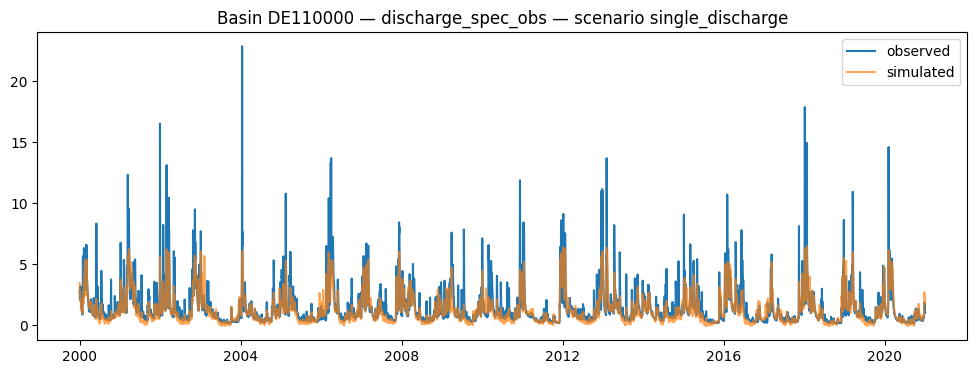

In [25]:
import matplotlib.pyplot as plt, random

scenario_name = "single_discharge"
target_of_interest = "discharge_spec_obs"
zarr_path = config.path_save_folder / f"testing_results_{scenario_name}.zarr"
test_results = xr.open_zarr(zarr_path)

basin = random.choice(list(test_results.gauge_id.values))
y_obs = test_results.sel(gauge_id=basin, feature=target_of_interest)["y_obs"].to_pandas().dropna()
y_sim = test_results.sel(gauge_id=basin, feature=target_of_interest)["y_sim"].to_pandas().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_obs.index, y_obs.values, label="observed")
ax.plot(y_sim.index, y_sim.values, label="simulated", alpha=0.7)
ax.set_title(f"Basin {basin} — {target_of_interest} — scenario {scenario_name}")
ax.legend()
plt.show()
